<a href="https://colab.research.google.com/github/ParmeetKaur1708/Mental-Health-Prediction/blob/main/final_project_mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sklearn
import numpy as np

In [ ]:
df = pd.read_csv("/content/Student Social Media And Mental Health Impact.csv")

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.shape

(5000, 13)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

I have to check both stress level and give mental health score to a person. so i will have to train two models simultaneously to achieve the desired result.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
# Feature Engineering

df["Social_Media_Intensity"] = (
    df["Avg_Daily_Usage_Hours"] *
    np.log1p(df["Daily_Unlocks"])
)


df["Sleep_Impact"] = (
    8 - df["Sleep_Hours_Per_Night"]
)


df["Social_Media_Dependency"] = (
    df["Avg_Daily_Usage_Hours"] /
    (df["Study_Hours"] + 1)
)


df["Healthy_Lifestyle_Score"] = (
    df["Sleep_Hours_Per_Night"]*0.6 +
    df["Physical_Activity_Hours"]*0.4
)


df["Wellness_Index"] = (
    df["Sleep_Hours_Per_Night"] +
    df["Physical_Activity_Hours"] +
    df["Study_Hours"] -
    df["Avg_Daily_Usage_Hours"]
)

In [ ]:
X = df.drop(["Stress_Level","Mental_Health_Score"],axis=1)
# Targets coz two models are to be trained
y_stress = df["Stress_Level"]
y_health = df["Mental_Health_Score"]

In [ ]:
numeric_features = ["Age","Avg_Daily_Usage_Hours","Daily_Unlocks","Study_Hours",
                    "Physical_Activity_Hours","Sleep_Hours_Per_Night","Social_Media_Intensity",
                    "Sleep_Impact", "Social_Media_Dependency", "Healthy_Lifestyle_Score", "Wellness_Index"]
categorical_features = ["Gender","Country","Academic_Level","Most_Used_Platform",
                        "Purpose_Of_Use"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
preprocessor = ColumnTransformer( transformers=[
      (
            "num",StandardScaler(),numeric_features
        ),

        (
            "cat",OneHotEncoder( handle_unknown="ignore"),categorical_features
        )])

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Social_Media_Intensity,Sleep_Impact,Social_Media_Dependency,Healthy_Lifestyle_Score,Wellness_Index
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,19.621099,1.3,0.727273,4.90,9.4
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,6.886504,-0.6,0.200000,6.12,16.4
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,23.542772,1.3,0.920000,4.74,7.9
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,37.787139,2.6,3.500000,3.92,1.1
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,41.042030,3.0,3.750000,3.44,-0.4


Test train splitting

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X,y_stress,test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
stress_model = Pipeline(

steps=[("preprocessor",preprocessor),("classifier",
                                      RandomForestClassifier(n_estimators=200,random_state=42))])

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Social_Media_Intensity',
       'Sleep_Impact', 'Social_Media_Dependency', 'Healthy_Lifestyle_Score',
       'Wellness_Index'],
      dtype='object')

In [ ]:
stress_model.fit(X_train_s,y_train_s)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Study_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night',
                                                   'Social_Media_Intensity',
                                                   'Sleep_Impact',
                                                   'Social_Media_Dependency',
                                                   'Healthy_Lifestyle_Score',
                                                   'Wellness_Index']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [ ]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,mean_absolute_error,
                             mean_squared_error,r2_score)


In [ ]:
stress_prediction = stress_model.predict(X_test_s)
print(accuracy_score(y_test_s,stress_prediction))
print(classification_report(y_test_s,stress_prediction))

0.875
              precision    recall  f1-score   support

        High       0.81      0.82      0.82       259
         Low       0.90      0.88      0.89       132
      Medium       0.86      0.88      0.87       257
   Very High       0.93      0.91      0.92       352

    accuracy                           0.88      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.88      0.88      0.88      1000



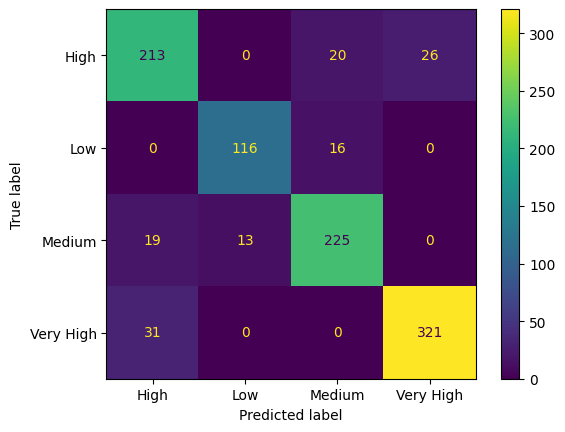

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_s,
    stress_prediction
)

plt.show()

Mental Health Score Prediction

In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X,y_health,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
health_model = Pipeline(
steps=[("preprocessor",preprocessor),("regressor",RandomForestRegressor(n_estimators=200,random_state=42))])

In [ ]:
health_model.fit( X_train_m,y_train_m)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Study_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night',
                                                   'Social_Media_Intensity',
                                                   'Sleep_Impact',
                                                   'Social_Media_Dependency',
                                                   'Healthy_Lifestyle_Score',
                                                   'Wellness_Index']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country',
                                                   'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
health_prediction = health_model.predict(X_test_m)
print(
    "MAE:",
    mean_absolute_error(y_test_m,health_prediction)
)
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test_m,health_prediction))
)
print(
    "R2 Score:",
    r2_score(y_test_m,health_prediction)
)

MAE: 0.2953829750000001
RMSE: 0.4101115410097296
R2 Score: 0.9030107518495235


In [ ]:
df["Mental_Health_Score"].describe()

,Mental_Health_Score
count,5000.000000
mean,6.230980
std,1.278701
min,3.600000
25%,5.100000
50%,6.100000
75%,7.100000
max,9.400000


In [ ]:
import joblib

In [ ]:
joblib.dump(
    stress_model,
    "stress_model.pkl"
)


joblib.dump(
    health_model,
    "mental_health_model.pkl"
)

['mental_health_model.pkl']

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Social_Media_Intensity',
       'Sleep_Impact', 'Social_Media_Dependency', 'Healthy_Lifestyle_Score',
       'Wellness_Index'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd

new_person = pd.DataFrame({

    "Age": [21],
    "Gender": ["Female"],
    "Country": ["India"],
    "Academic_Level": ["Undergraduate"],
    "Most_Used_Platform": ["Instagram"],
    "Purpose_Of_Use": ["Entertainment"],

    "Avg_Daily_Usage_Hours": [5],
    "Daily_Unlocks": [80],
    "Study_Hours": [3],
    "Physical_Activity_Hours": [1],
    "Sleep_Hours_Per_Night": [6],

    # Engineered Features
    "Social_Media_Intensity": [5 * np.log1p(80)],
    "Social_Media_Dependency": [5 / (3 + 1)],
    "Sleep_Impact": [8 - 6],
    "Wellness_Index": [6 + 1 + 3 - 5]

})

In [ ]:
def create_features(df):

    df = df.copy()

    df["Social_Media_Intensity"] = (
        df["Avg_Daily_Usage_Hours"] *
        np.log1p(df["Daily_Unlocks"])
    )

    df["Sleep_Impact"] = (
        8 - df["Sleep_Hours_Per_Night"]
    )

    df["Social_Media_Dependency"] = (
        df["Avg_Daily_Usage_Hours"] /
        (df["Study_Hours"] + 1)
    )

    df["Healthy_Lifestyle_Score"] = (
        df["Sleep_Hours_Per_Night"] * 0.6 +
        df["Physical_Activity_Hours"] * 0.4
    )

    df["Wellness_Index"] = (
        df["Sleep_Hours_Per_Night"] +
        df["Physical_Activity_Hours"] +
        df["Study_Hours"] -
        df["Avg_Daily_Usage_Hours"]
    )

    return df

In [ ]:
new_person = create_features(new_person)

stress_result = stress_model.predict(new_person)
health_result = health_model.predict(new_person)

In [ ]:
stress_result = stress_model.predict(
    new_person
)


health_result = health_model.predict(
    new_person
)


print(
    "Stress Level:",
    stress_result[0]
)


print(
    "Mental Health Score:",
    health_result[0]
)

Stress Level: High
Mental Health Score: 6.066500000000001
